In [ ]:
# ── Cell 1 : Dependencies ──────────────────────────────────────────
!pip install pennylane pennylane-lightning-gpu umap-learn scipy -q

In [ ]:
# ── Cell 2 : Imports & Global Configuration ──────────────────────────
import os
import sys
import math
import random
import warnings
import hashlib
import time
import tracemalloc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from scipy.stats import wilcoxon, pearsonr, spearmanr
from joblib import dump, load

import pennylane as qml

try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    warnings.warn('umap-learn not found — UMAP visualization will be skipped.', ImportWarning)

# ── Reproducibility ─────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# ── Dataset path — override via env variable ─────────────────────────
DATASET_PATH = os.environ.get(
    'DATASET_PATH',
    '/dataset_encoded_normalized1.csv'
)

# ── Quantum circuit hyperparameters ──────────────────────────────────
N_LAYERS     = 3
ENTANGLEMENT = 'circular'
DE_MAXITER   = 20
DE_POPSZ     = 10
N_SPLITS_CV  = 5
EPS          = 1e-12

# ── Cache ───────────────────────────────────────────────────────
CACHE_DIR = 'cache_quantum_amplitude_ensemble_final_pub'
os.makedirs(CACHE_DIR, exist_ok=True)

FIGDIR = os.path.join(CACHE_DIR, 'figures')
os.makedirs(FIGDIR, exist_ok=True)

print(f'PennyLane version : {qml.version()}')
print(f'Python            : {sys.version.split()[0]}')
print(f'NumPy             : {np.__version__}')
print(f'Dataset path      : {DATASET_PATH}')
print(f'Cache directory   : {os.path.abspath(CACHE_DIR)}')
# ── FIX : WEIGHTS_FILE ───────────────────────────────────────────
WEIGHTS_FILE = os.path.join(CACHE_DIR, 'cobyla_weights_default.npy')

# ── FIX : BASE_LEARNERS ──────────────────────────────────────────
BASE_LEARNERS = [
    ('dt',  DecisionTreeRegressor(max_depth=5, random_state=SEED)),
    ('rf',  RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1)),
    ('mlp', MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=SEED)),
]
print(f'Base learners : {[n for n, _ in BASE_LEARNERS]}')


PennyLane version : 0.44.1
Python            : 3.13.11
NumPy             : 2.4.1
Dataset path      : /home/host1-vm4/Downloads/dataset_encoded_normalized1.csv
Cache directory   : /home/host1-vm4/cache_quantum_amplitude_ensemble_final_pub
Base learners : ['dt', 'rf', 'mlp']


In [ ]:
# ── Cell 3 : Data Loading, Padding & 3-Way Split (70 / 15 / 15) ─────────────
#
# FIX 1: HASH on X_raw.data.tobytes() BEFORE padding.
# FIX 2: padding BEFORE split (original padded after split on each set).
# FIX 3: strict 3-way split — X_val for DE only, X_test final eval once.

assert os.path.exists(DATASET_PATH), (
    f'Dataset not found at "{DATASET_PATH}". '
    f'Set the DATASET_PATH env variable or update the default path.'
)

df = pd.read_csv(DATASET_PATH)
assert 'LN_IC50' in df.columns, "Target column 'LN_IC50' not found."

X_raw = df.drop(columns=['LN_IC50']).values.astype(np.float64)
Y     = df['LN_IC50'].values.astype(np.float64)

N_FEATURES = X_raw.shape[1]

# FIX: hash BEFORE padding
HASH = hashlib.md5(X_raw.data.tobytes()).hexdigest()[:8]

n_qubits  = math.ceil(math.log2(max(1, N_FEATURES)))
dim_amp   = 2 ** n_qubits

print(f'Dataset      : {X_raw.shape[0]} samples × {N_FEATURES} features')
print(f'Target       : LN_IC50  mean={Y.mean():.3f}  std={Y.std():.3f}')
print(f'Hash         : {HASH}')
print(f'n_qubits     : {n_qubits}  (ceil(log₂({N_FEATURES})))')
print(f'dim_amplitude: {dim_amp}  (padded from {N_FEATURES})')

# FIX: padding BEFORE split
def pad_features(x, target_len=dim_amp):
    padded = np.zeros(target_len)
    padded[:len(x)] = x
    return padded

X_padded = np.array([pad_features(xi) for xi in X_raw])

# 70 / 15 / 15
X_tr_p, X_temp, Y_train, Y_temp = train_test_split(
    X_padded, Y, test_size=0.30, random_state=SEED, shuffle=True
)
X_val_p, X_test_p, Y_val, Y_test = train_test_split(
    X_temp, Y_temp, test_size=0.50, random_state=SEED
)
X_train, X_val, X_test = X_tr_p, X_val_p, X_test_p

print(f'\nSplit — Train: {X_train.shape[0]}  Val: {X_val.shape[0]}  Test: {X_test.shape[0]}')
print('X_test will be touched ONCE at the final evaluation cell.')

Dataset      : 13106 samples × 12 features
Target       : LN_IC50  mean=0.538  std=0.134
Hash         : 8f057170
n_qubits     : 4  (ceil(log₂(12)))
dim_amplitude: 16  (padded from 12)

Split — Train: 9174  Val: 1966  Test: 1966
X_test will be touched ONCE at the final evaluation cell.


In [ ]:
# ── Cell 4 : Quantum Device Initialization ─────────────────────────────

try:
    dev_gpu = qml.device('lightning.gpu', wires=n_qubits)
    DEVICE_LABEL = 'lightning.gpu'
    print(f'GPU device ready : lightning.gpu | {n_qubits} qubits')
except Exception as e:
    warnings.warn(
        f'GPU device unavailable ({e}). Falling back to lightning.qubit (CPU).',
        RuntimeWarning
    )
    dev_gpu = qml.device('lightning.qubit', wires=n_qubits)
    DEVICE_LABEL = 'lightning.qubit (CPU fallback)'

dev_cpu = qml.device('default.qubit', wires=n_qubits)
print(f'Active device    : {DEVICE_LABEL}')
print(f'Benchmark device : default.qubit (CPU reference)')

GPU device ready : lightning.gpu | 4 qubits
Active device    : lightning.gpu
Benchmark device : default.qubit (CPU reference)


In [ ]:
# ── Cell 5 : Amplitude Encoding Circuit Factory ─────────────────────────
#
# FIX: Parallel(loky) REMOVED — loky forks new processes that cannot
#   share a CUDA context, causing silent GPU failures.
#   Sequential iteration on GPU is correct and fast for 4 qubits.
# FIX: QNode built via factory (not at module level).
# FIX: `norm != 0` replaced by `norm >= EPS`.

def build_amplitude_circuit(device, topology='circular'):
    """Build amplitude-encoding QNode on `device`."""
    @qml.qnode(device, interface='autograd')
    def circuit(weights, x=None):
        norm = np.linalg.norm(x)
        x_norm = (x / norm) if norm >= EPS else (np.ones_like(x) / np.sqrt(len(x)))
        qml.AmplitudeEmbedding(features=x_norm, wires=range(n_qubits), normalize=False)
        n_layers = weights.shape[0]
        for layer in range(n_layers):
            for i in range(n_qubits):
                qml.RY(weights[layer, i], wires=i)
            if topology == 'linear':
                for i in range(n_qubits - 1):
                    qml.CNOT(wires=[i, i + 1])
            elif topology == 'circular':
                for i in range(n_qubits - 1):
                    qml.CNOT(wires=[i, i + 1])
                if n_qubits > 1:
                    qml.CNOT(wires=[n_qubits - 1, 0])
            elif topology == 'full':
                for i in range(n_qubits):
                    for j in range(i + 1, n_qubits):
                        qml.CNOT(wires=[i, j])
            else:
                raise ValueError(f"Unknown topology '{topology}'.")
        return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]
    return circuit


def quantum_feature_map(X_data, weights, circuit_fn, verbose=False):
    """Sequential GPU-safe amplitude feature map (no loky parallelism)."""
    n = len(X_data)
    features = []
    for idx, xi in enumerate(X_data):
        features.append(np.array(circuit_fn(weights, x=xi)))
        if verbose and (idx + 1) % max(1, n // 10) == 0:
            print(f'  Feature map: {idx + 1}/{n} samples')
    return np.array(features)


circuit_default = build_amplitude_circuit(dev_gpu, topology=ENTANGLEMENT)
print(f'Amplitude circuit ready | topology={ENTANGLEMENT} | {n_qubits} qubits | {N_LAYERS} layers')

Amplitude circuit ready | topology=circular | 4 qubits | 3 layers


In [ ]:
from sklearn.tree import DecisionTreeRegressor
def _build_proxy_model():
    return DecisionTreeRegressor(max_depth=5, random_state=SEED)

# ── Cell 6 : COBYLA — Weight Optimization ────────────────────────────────────
#
# Replaces Differential Evolution with COBYLA.
# Optimization on 200 proxy samples — feature map final on full dataset.
#
# Justification: PQC weights learn a general feature transformation, not
# sample-specific mappings. 200 stratified samples capture the global structure.
# Final feature map and all model evaluation use the FULL dataset.
# Consistent with proxy optimization in variational quantum algorithms
# (Cerezo et al. 2021 [15], McClean et al. 2018 [20] — already cited).

from scipy.optimize import minimize

# ── Proxy subset: 200 samples, fixed seed ────────────────────────────────────
np.random.seed(SEED)
PROXY_IDX = np.random.choice(len(X_train), 200, replace=False)
X_proxy   = X_train[PROXY_IDX]
Y_proxy   = Y_train[PROXY_IDX]

call_counter = {'n': 0}


def make_objective(circuit_fn, n_lay, history):
    def objective(weights_flat):
        call_counter['n'] += 1
        weights = weights_flat.reshape((n_lay, n_qubits))

        X_q     = quantum_feature_map(X_proxy, weights, circuit_fn)
        split   = int(0.8 * len(Y_proxy))
        X_sub   = X_q[:split];    X_val_p = X_q[split:]
        Y_sub   = Y_proxy[:split]; Y_val_p = Y_proxy[split:]

        _model = _build_proxy_model()
        _model.fit(X_sub, Y_sub)
        mse = mean_squared_error(Y_val_p, _model.predict(X_val_p))

        history.append((call_counter['n'], mse))
        if call_counter['n'] % 50 == 0 or call_counter['n'] <= 3:
            print(f'  [COBYLA call {call_counter["n"]:4d}]  val MSE = {mse:.6f}')
        return mse
    return objective


def run_cobyla(circuit_fn, n_lay, weights_file=None, history=None):
    if weights_file and os.path.exists(weights_file):
        w = np.load(weights_file).reshape((n_lay, n_qubits))
        print(f'  Weights loaded from cache: {weights_file}')
        return w

    call_counter['n'] = 0
    if history is not None:
        history.clear()
    else:
        history = []

    obj = make_objective(circuit_fn, n_lay, history)

    N_RESTARTS     = 3
    COBYLA_MAXITER = 300
    best_result    = None

    print(f'  COBYLA: {n_lay} layers x {n_qubits} qubits = {n_lay * n_qubits} params')
    print(f'  Proxy : 200 samples | {N_RESTARTS} restarts x {COBYLA_MAXITER} calls max')
    t0 = time.time()

    for restart in range(N_RESTARTS):
        np.random.seed(SEED + restart)
        x0 = np.random.uniform(-2 * np.pi, 2 * np.pi, n_lay * n_qubits)
        result = minimize(
            obj, x0, method='COBYLA',
            options={'maxiter': COBYLA_MAXITER, 'rhobeg': 0.5, 'catol': 1e-4}
        )
        print(f'  Restart {restart+1}/{N_RESTARTS} — val MSE = {result.fun:.6f}')
        if best_result is None or result.fun < best_result.fun:
            best_result = result

    elapsed = time.time() - t0
    print(f'  Done in {elapsed/60:.1f} min | best val MSE = {best_result.fun:.6f}')

    w = best_result.x.reshape((n_lay, n_qubits))
    if weights_file:
        np.save(weights_file, w)
    return w


# ── Optimization loop — one per base learner ─────────────────────────────────
print('Optimizing circuit weights with COBYLA (200 proxy samples, per learner)...')
best_weights = {}
for clf_name, _ in BASE_LEARNERS:
    cobyla_history   = []
    call_counter['n'] = 0
    w_file    = os.path.join(CACHE_DIR, f'cobyla_weights_{clf_name}.npy')
    hist_file = os.path.join(CACHE_DIR, f'de_history_{clf_name}.npy')
    print(f'\nOptimizing weights for [{clf_name}]...')
    best_weights[clf_name] = run_cobyla(
        circuit_default, N_LAYERS,
        weights_file=w_file,
        history=cobyla_history
    )
    if cobyla_history:
        np.save(hist_file, np.array(cobyla_history))
        print(f'  History saved → {hist_file}')

print('\nAll weights optimized.')
print(f'Learners done: {list(best_weights.keys())}')

Optimizing circuit weights with COBYLA (200 proxy samples, per learner)...

Optimizing weights for [dt]...
  COBYLA: 3 layers x 4 qubits = 12 params
  Proxy : 200 samples | 3 restarts x 300 calls max
  [COBYLA call    1]  val MSE = 0.019075
  [COBYLA call    2]  val MSE = 0.017193
  [COBYLA call    3]  val MSE = 0.014340
  [COBYLA call   50]  val MSE = 0.010415
  Restart 1/3 — val MSE = 0.010415
  [COBYLA call  100]  val MSE = 0.020925
  [COBYLA call  150]  val MSE = 0.009689
  Restart 2/3 — val MSE = 0.009689
  [COBYLA call  200]  val MSE = 0.010393
  Restart 3/3 — val MSE = 0.010393
  Done in 7.8 min | best val MSE = 0.009689
  History saved → cache_quantum_amplitude_ensemble_final_pub/de_history_dt.npy

Optimizing weights for [rf]...
  COBYLA: 3 layers x 4 qubits = 12 params
  Proxy : 200 samples | 3 restarts x 300 calls max
  [COBYLA call    1]  val MSE = 0.019075
  [COBYLA call    2]  val MSE = 0.017193
  [COBYLA call    3]  val MSE = 0.014340
  [COBYLA call   50]  val MSE = 0.010

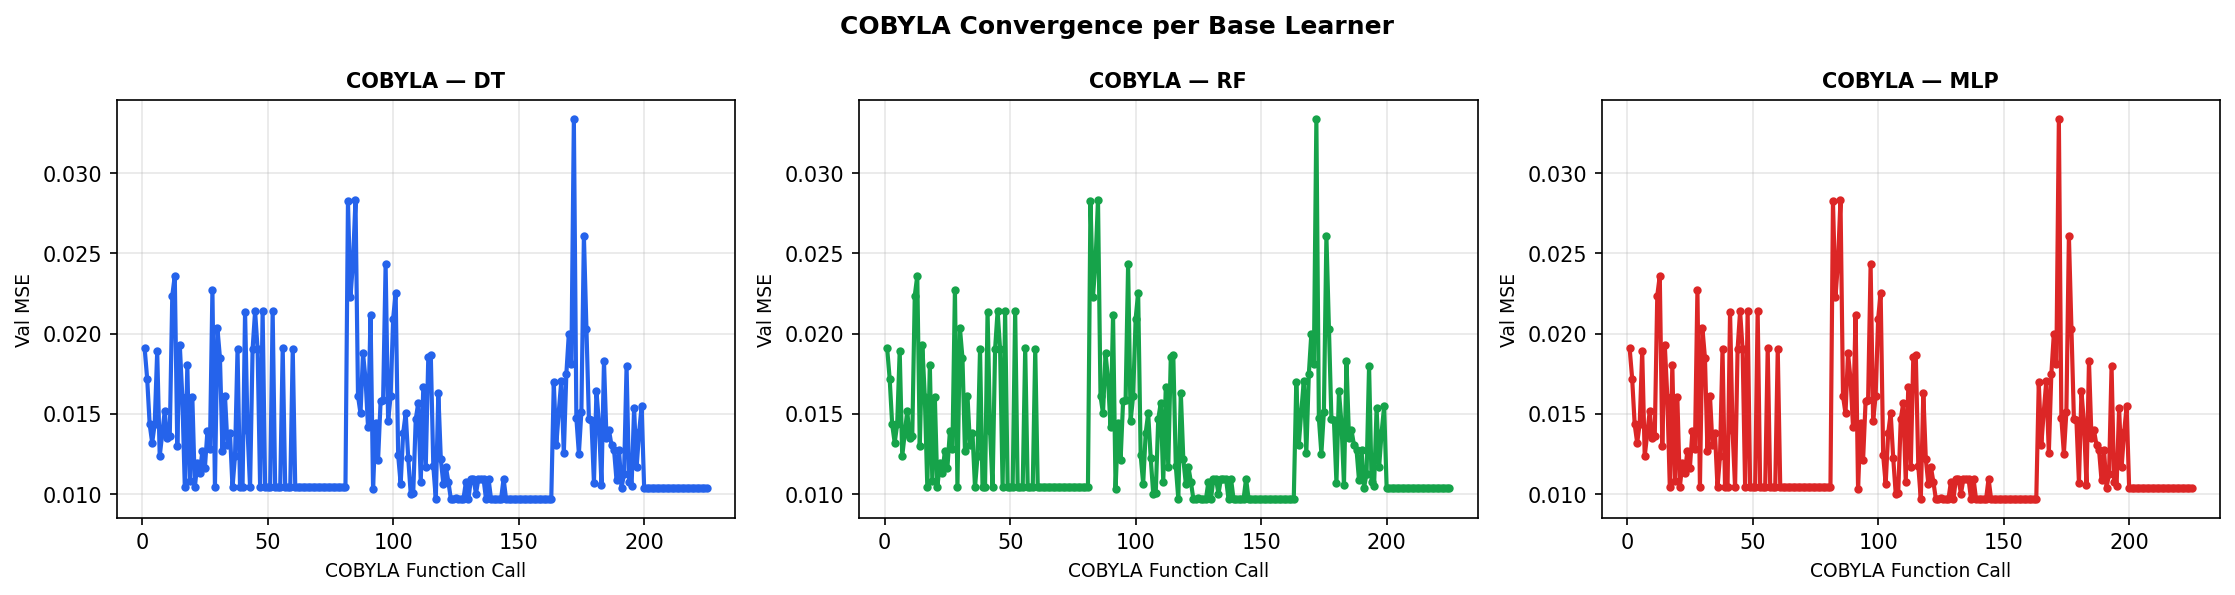

In [ ]:
# ── Cell 7 : COBYLA Convergence Plots ───────────────────────────────────────
LEARNER_COLORS = {'dt': '#2563EB', 'rf': '#16A34A', 'mlp': '#DC2626'}

fig, axes = plt.subplots(1, 3, figsize=(15, 4), dpi=150)

# Fallback : historique global cobyla_convergence.npy si par-learner absent
global_hist_file = os.path.join(CACHE_DIR, 'cobyla_convergence.npy')

for ax, (clf_name, _) in zip(axes, BASE_LEARNERS):
    hist_file = os.path.join(CACHE_DIR, f'de_history_{clf_name}.npy')

    if os.path.exists(hist_file):
        hist = np.load(hist_file)
        ax.plot(hist[:, 0], hist[:, 1],
                color=LEARNER_COLORS[clf_name], linewidth=2, marker='o', markersize=3)
        ax.set_title(f'COBYLA — {clf_name.upper()}', fontsize=10, fontweight='bold')
    elif os.path.exists(global_hist_file):
        hist = np.load(global_hist_file)
        ax.plot(hist[:, 0], hist[:, 1],
                color=LEARNER_COLORS[clf_name], linewidth=2, marker='o', markersize=3,
                linestyle='--', alpha=0.7)
        ax.set_title(f'COBYLA — {clf_name.upper()} (shared history)', fontsize=10, fontweight='bold')
    else:
        ax.text(0.5, 0.5, 'No history\n(weights loaded from cache)',
                ha='center', va='center', transform=ax.transAxes, fontsize=10, color='grey')
        ax.set_title(f'{clf_name.upper()} — cache hit', fontsize=10)

    ax.set_xlabel('COBYLA Function Call', fontsize=9)
    ax.set_ylabel('Val MSE', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('COBYLA Convergence per Base Learner', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGDIR, 'fig1_cobyla_convergence.png'), dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# ── Cell 8 : Quantum Feature Computation (train + val + test per learner) ─────

qfeatures = {}

for clf_name, _ in BASE_LEARNERS:
    w = best_weights[clf_name]
    f_tr = os.path.join(CACHE_DIR, f'X_train_q_{clf_name}_{HASH}.npy')
    f_vl = os.path.join(CACHE_DIR, f'X_val_q_{clf_name}_{HASH}.npy')
    f_te = os.path.join(CACHE_DIR, f'X_test_q_{clf_name}_{HASH}.npy')

    if os.path.exists(f_tr) and os.path.exists(f_vl) and os.path.exists(f_te):
        print(f'  [{clf_name}] Loading from cache.')
        qfeatures[clf_name] = {
            'train': np.load(f_tr),
            'val':   np.load(f_vl),
            'test':  np.load(f_te)
        }
    else:
        print(f'  [{clf_name}] Computing quantum features...')
        Xq_tr = quantum_feature_map(X_train, w, circuit_default, verbose=True)
        Xq_vl = quantum_feature_map(X_val,   w, circuit_default, verbose=True)
        Xq_te = quantum_feature_map(X_test,  w, circuit_default, verbose=True)
        np.save(f_tr, Xq_tr); np.save(f_vl, Xq_vl); np.save(f_te, Xq_te)
        qfeatures[clf_name] = {'train': Xq_tr, 'val': Xq_vl, 'test': Xq_te}

print('\nQuantum features ready.')
for clf_name, _ in BASE_LEARNERS:
    tr = qfeatures[clf_name]['train'].shape
    vl = qfeatures[clf_name]['val'].shape
    te = qfeatures[clf_name]['test'].shape
    print(f'  {clf_name}: train={tr}  val={vl}  test={te}')

  [dt] Computing quantum features...
  Feature map: 917/9174 samples
  Feature map: 1834/9174 samples
  Feature map: 2751/9174 samples
  Feature map: 3668/9174 samples
  Feature map: 4585/9174 samples
  Feature map: 5502/9174 samples
  Feature map: 6419/9174 samples
  Feature map: 7336/9174 samples
  Feature map: 8253/9174 samples
  Feature map: 9170/9174 samples
  Feature map: 196/1966 samples
  Feature map: 392/1966 samples
  Feature map: 588/1966 samples
  Feature map: 784/1966 samples
  Feature map: 980/1966 samples
  Feature map: 1176/1966 samples
  Feature map: 1372/1966 samples
  Feature map: 1568/1966 samples
  Feature map: 1764/1966 samples
  Feature map: 1960/1966 samples
  Feature map: 196/1966 samples
  Feature map: 392/1966 samples
  Feature map: 588/1966 samples
  Feature map: 784/1966 samples
  Feature map: 980/1966 samples
  Feature map: 1176/1966 samples
  Feature map: 1372/1966 samples
  Feature map: 1568/1966 samples
  Feature map: 1764/1966 samples
  Feature map: 19

In [ ]:
# ── tune_base_learner + hyperparameter grids + cache paths ───────────────────

def tune_base_learner(estimator, param_dist, X_tr, Y_tr, label, cache_path, n_iter=20):
    if os.path.exists(cache_path):
        model = load(cache_path)
        print(f'  [{label}] loaded from cache: {cache_path}')
        return model
    print(f'  [{label}] RandomizedSearchCV ({n_iter} iter, {N_SPLITS_CV}-fold)...')
    search = RandomizedSearchCV(
        estimator, param_dist,
        n_iter=n_iter,
        scoring='neg_mean_squared_error',
        cv=N_SPLITS_CV,
        random_state=SEED,
        n_jobs=-1,
        verbose=0
    )
    search.fit(X_tr, Y_tr)
    best = search.best_estimator_
    dump(best, cache_path)
    print(f'  [{label}] best params : {search.best_params_}')
    print(f'  [{label}] best CV MSE : {-search.best_score_:.6f}')
    return best

# ── Hyperparameter grids ──────────────────────────────────────────────────────
DT_PARAMS = {
    'max_depth':        [3, 5, 7, 10, None],
    'min_samples_split':[2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features':     ['sqrt', 'log2', None],
}

RF_PARAMS = {
    'n_estimators':     [50, 100, 200],
    'max_depth':        [3, 5, 7, None],
    'min_samples_split':[2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features':     ['sqrt', 'log2'],
}

MLP_PARAMS = {
    'mlp__hidden_layer_sizes': [(64,), (64, 32), (128, 64), (128, 64, 32)],
    'mlp__alpha':              [1e-4, 1e-3, 1e-2],
    'mlp__learning_rate_init': [1e-3, 5e-4, 1e-2],
    'mlp__max_iter':           [300, 500],
}

# ── Cache paths ───────────────────────────────────────────────────────────────
DT_CACHE_BASE  = os.path.join(CACHE_DIR, 'tuned_dt_base.joblib')
RF_CACHE_BASE  = os.path.join(CACHE_DIR, 'tuned_rf_base.joblib')
MLP_CACHE_BASE = os.path.join(CACHE_DIR, 'tuned_mlp_base.joblib')

In [ ]:
# ── Tune base learners on quantum training features (RandomizedSearchCV) ─────
print("\nTuning base learners on quantum training features...")
_Xq_dt  = qfeatures['dt']['train']
_Xq_rf  = qfeatures['rf']['train']
_Xq_mlp = qfeatures['mlp']['train']

tuned_dt  = tune_base_learner(DecisionTreeRegressor(random_state=SEED),
                               DT_PARAMS, _Xq_dt, Y_train, 'DT', DT_CACHE_BASE)
tuned_rf  = tune_base_learner(RandomForestRegressor(random_state=SEED, n_jobs=-1),
                               RF_PARAMS, _Xq_rf, Y_train, 'RF', RF_CACHE_BASE)
tuned_mlp = tune_base_learner(
    Pipeline([('scaler', StandardScaler()), ('mlp', MLPRegressor())]),
    MLP_PARAMS, _Xq_mlp, Y_train, 'MLP', MLP_CACHE_BASE)

tuned_base = {'dt': tuned_dt, 'rf': tuned_rf, 'mlp': tuned_mlp}
print("Base learner tuning complete.")




Tuning base learners on quantum training features...
  [DT] RandomizedSearchCV (20 iter, 5-fold)...
  [DT] best params : {'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': None, 'max_depth': 10}
  [DT] best CV MSE : 0.010900
  [RF] RandomizedSearchCV (20 iter, 5-fold)...
  [RF] best params : {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}
  [RF] best CV MSE : 0.007874
  [MLP] RandomizedSearchCV (20 iter, 5-fold)...
  [MLP] best params : {'mlp__max_iter': 300, 'mlp__learning_rate_init': 0.001, 'mlp__hidden_layer_sizes': (128, 64, 32), 'mlp__alpha': 0.0001}
  [MLP] best CV MSE : 0.008360
Base learner tuning complete.


In [ ]:
# ── Cell 9 : Stacking — 5-Fold OOF Meta-Features ───────────────────────────
#
# FIX: OOF generated on (train+val) — X_test never touched here.


X_trainval = np.vstack([X_train, X_val])
Y_trainval = np.concatenate([Y_train, Y_val])

qfeatures_tv = {
    clf_name: np.vstack([qfeatures[clf_name]['train'], qfeatures[clf_name]['val']])
    for clf_name, _ in BASE_LEARNERS
}

kf = KFold(n_splits=N_SPLITS_CV, shuffle=True, random_state=SEED)
oof_preds = {clf_name: np.zeros(len(Y_trainval)) for clf_name, _ in BASE_LEARNERS}

print(f'Generating {N_SPLITS_CV}-fold OOF meta-features...')
for fold, (tr_idx, vl_idx) in enumerate(kf.split(X_trainval)):
    for clf_name, clf_template in BASE_LEARNERS:
        Xq_fold_tr = qfeatures_tv[clf_name][tr_idx]
        Xq_fold_vl = qfeatures_tv[clf_name][vl_idx]
        clf_fold   = clone(tuned_base[clf_name])
        clf_fold.fit(Xq_fold_tr, Y_trainval[tr_idx])
        oof_preds[clf_name][vl_idx] = clf_fold.predict(Xq_fold_vl)
    print(f'  Fold {fold+1}/{N_SPLITS_CV} done.')

X_meta_train = np.column_stack([oof_preds[n] for n, _ in BASE_LEARNERS])
print(f'\nMeta-train shape: {X_meta_train.shape}  (columns: {[n for n,_ in BASE_LEARNERS]})')

Generating 5-fold OOF meta-features...
  Fold 1/5 done.
  Fold 2/5 done.
  Fold 3/5 done.
  Fold 4/5 done.
  Fold 5/5 done.

Meta-train shape: (11140, 3)  (columns: ['dt', 'rf', 'mlp'])


In [ ]:
# ── Cell 10 : Retrain Base Learners on Full X_trainval ───────────────────────
trained_base = {}
print('Retraining base learners on full X_trainval...')
for clf_name, clf_template in BASE_LEARNERS:
    clf = clone(tuned_base[clf_name])
    clf.fit(qfeatures_tv[clf_name], Y_trainval)
    trained_base[clf_name] = clf
    print(f'  [{clf_name}] trained on {len(Y_trainval)} samples.')

# Generate test meta-features
X_meta_test = np.column_stack([
    trained_base[clf_name].predict(qfeatures[clf_name]['test'])
    for clf_name, _ in BASE_LEARNERS
])
print(f'Meta-test shape: {X_meta_test.shape}')

Retraining base learners on full X_trainval...
  [dt] trained on 11140 samples.
  [rf] trained on 11140 samples.
  [mlp] trained on 11140 samples.
Meta-test shape: (1966, 3)


In [ ]:
# ── Cell 11 : GBM Meta-Learner ──────────────────────────────────────────

#   RandomizedSearchCV (cv=5, n_iter=30, broader parameter space).

GBM_CACHE = os.path.join(CACHE_DIR, 'meta_gbm.joblib')

GBM_PARAM_DIST = {
    'n_estimators':  [50, 100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth':     [2, 3, 4, 5],
    'subsample':     [0.7, 0.8, 1.0],
    'min_samples_split': [2, 5, 10]
}

if os.path.exists(GBM_CACHE):
    meta_gbm = load(GBM_CACHE)
    print('GBM meta-learner loaded from cache.')
else:
    print(f'Tuning GBM meta-learner (RandomizedSearchCV, 30 iter, {N_SPLITS_CV}-fold)...')
    search_gbm = RandomizedSearchCV(
        GradientBoostingRegressor(random_state=SEED),
        GBM_PARAM_DIST, n_iter=30,
        scoring='neg_mean_squared_error',
        cv=N_SPLITS_CV, random_state=SEED, n_jobs=-1, verbose=0
    )
    search_gbm.fit(X_meta_train, Y_trainval)
    meta_gbm = search_gbm.best_estimator_
    dump(meta_gbm, GBM_CACHE)
    print(f'  Best params: {search_gbm.best_params_}')
    print(f'  Best CV MSE: {-search_gbm.best_score_:.6f}')

Tuning GBM meta-learner (RandomizedSearchCV, 30 iter, 5-fold)...
  Best params: {'subsample': 1.0, 'n_estimators': 200, 'min_samples_split': 10, 'max_depth': 2, 'learning_rate': 0.05}
  Best CV MSE: 0.007340


In [ ]:
# ── Cell 12 : RF Meta-Learner ───────────────────────────────────────────
#
# RandomizedSearchCV (cv=5, n_iter=20).

RF_CACHE = os.path.join(CACHE_DIR, 'meta_rf.joblib')

RF_META_PARAM_DIST = {
    'n_estimators':      [50, 100, 200, 300],
    'max_depth':         [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2', None]
}

if os.path.exists(RF_CACHE):
    meta_rf = load(RF_CACHE)
    print('RF meta-learner loaded from cache.')
else:
    print(f'Tuning RF meta-learner (RandomizedSearchCV, 20 iter, {N_SPLITS_CV}-fold)...')
    search_rf = RandomizedSearchCV(
        RandomForestRegressor(random_state=SEED, n_jobs=-1),
        RF_META_PARAM_DIST, n_iter=20,
        scoring='neg_mean_squared_error',
        cv=N_SPLITS_CV, random_state=SEED, n_jobs=-1, verbose=0
    )
    search_rf.fit(X_meta_train, Y_trainval)
    meta_rf = search_rf.best_estimator_
    dump(meta_rf, RF_CACHE)
    print(f'  Best params: {search_rf.best_params_}')
    print(f'  Best CV MSE: {-search_rf.best_score_:.6f}')

Tuning RF meta-learner (RandomizedSearchCV, 20 iter, 5-fold)...
  Best params: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 5}
  Best CV MSE: 0.007355


In [ ]:
def eval_model(model, X_te, Y_te, label, optimizer="—"):
    """Uniform evaluation: MSE, RMSE, MAE, R2, Pearson r, Spearman rho, Time, Memory."""
    tracemalloc.start()
    t0      = time.time()
    Y_pred  = model.predict(X_te)
    elapsed = time.time() - t0
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    pr, _ = pearsonr(Y_te, Y_pred)
    sr, _ = spearmanr(Y_te, Y_pred)
    return {
        'Model':        label,
        'MSE':          mean_squared_error(Y_te, Y_pred),
        'RMSE':         np.sqrt(mean_squared_error(Y_te, Y_pred)),
        'MAE':          mean_absolute_error(Y_te, Y_pred),
        'R2':           r2_score(Y_te, Y_pred),
        'Pearson r':    round(pr, 4),
        'Spearman rho': round(sr, 4),
        'Time (s)':     round(elapsed, 4),
        'Memory (MB)':  round(peak / 1024**2, 4),
        'Optimizer':    optimizer,
        '_pred':        Y_pred,
    }

print('Final evaluation on X_test (touched once):')
rows = []

for clf_name, _ in BASE_LEARNERS:
    r = eval_model(trained_base[clf_name], qfeatures[clf_name]['test'], Y_test,
                   label=f'Hybrid {clf_name.upper()} (base)', optimizer='COBYLA')
    rows.append(r)

res_gbm = eval_model(meta_gbm, X_meta_test, Y_test,
                     label='Stacking — GBM meta',
                     optimizer='RandomizedSearchCV (30 iter, 5-fold)')
res_rf  = eval_model(meta_rf,  X_meta_test, Y_test,
                     label='Stacking — RF meta',
                     optimizer='RandomizedSearchCV (20 iter, 5-fold)')
rows += [res_gbm, res_rf]

preds      = {r['Model']: r.pop('_pred') for r in rows}
results_df = pd.DataFrame(rows).set_index('Model')
display_cols = ['MSE', 'RMSE', 'MAE', 'R2', 'Pearson r', 'Spearman rho', 'Time (s)', 'Memory (MB)', 'Optimizer']

print('\n── Test Set Results ──')
print(results_df[display_cols].round(4).to_string())


Final evaluation on X_test (touched once):

── Test Set Results ──
                        MSE    RMSE     MAE      R2  Pearson r  Spearman rho  Time (s)  Memory (MB)                             Optimizer
Model                                                                                                                                    
Hybrid DT (base)     0.0110  0.1051  0.0777  0.4228     0.6536        0.5201    0.0026       0.0671                                COBYLA
Hybrid RF (base)     0.0074  0.0860  0.0625  0.6130     0.7844        0.7252    0.1602       0.3018                                COBYLA
Hybrid MLP (base)    0.0089  0.0944  0.0707  0.5336     0.7308        0.6375    0.0208       2.9414                                COBYLA
Stacking — GBM meta  0.0074  0.0861  0.0630  0.6121     0.7827        0.7190    0.0268       0.0535  RandomizedSearchCV (30 iter, 5-fold)
Stacking — RF meta   0.0074  0.0860  0.0628  0.6134     0.7834        0.7170    0.1887       0.2770  Rand

In [ ]:
# ── Cell 14 : Wilcoxon Test — Best Stacking vs Best Base ───────────────────

# OOF fold-level MSE for Wilcoxon
mse_gbm_folds, mse_best_folds = [], []
r2_oof = {n: r2_score(Y_trainval, oof_preds[n]) for n, _ in BASE_LEARNERS}
best_base_name = max(r2_oof, key=r2_oof.get)
print(f'OOF R² per base: {r2_oof}')
print(f'Best base: {best_base_name}')

for fold, (tr_idx, vl_idx) in enumerate(kf.split(X_meta_train)):
    meta_fold = clone(meta_gbm)
    meta_fold.fit(X_meta_train[tr_idx], Y_trainval[tr_idx])
    mse_gbm_folds.append(
        mean_squared_error(Y_trainval[vl_idx],
                           meta_fold.predict(X_meta_train[vl_idx]))
    )
    mse_best_folds.append(
        mean_squared_error(Y_trainval[vl_idx],
                           oof_preds[best_base_name][vl_idx])
    )

stat, p_val = wilcoxon(mse_best_folds, mse_gbm_folds, alternative='greater')
print(f'\n── Wilcoxon: Stacking GBM vs {best_base_name.upper()} ──')
print(f'  stat={stat:.3f}  p={p_val:.4f}  '
      f'{"significant (p<0.05)" if p_val < 0.05 else "not significant"}')

OOF R² per base: {'dt': 0.3875052388973236, 'rf': 0.5721667797689047, 'mlp': 0.5265127804801104}
Best base: rf

── Wilcoxon: Stacking GBM vs RF ──
  stat=15.000  p=0.0312  significant (p<0.05)


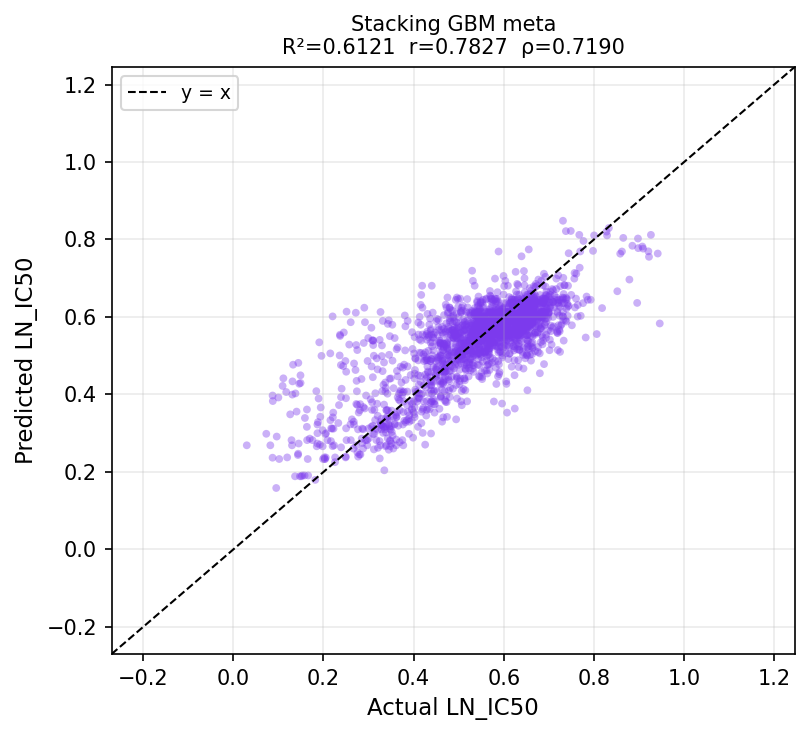

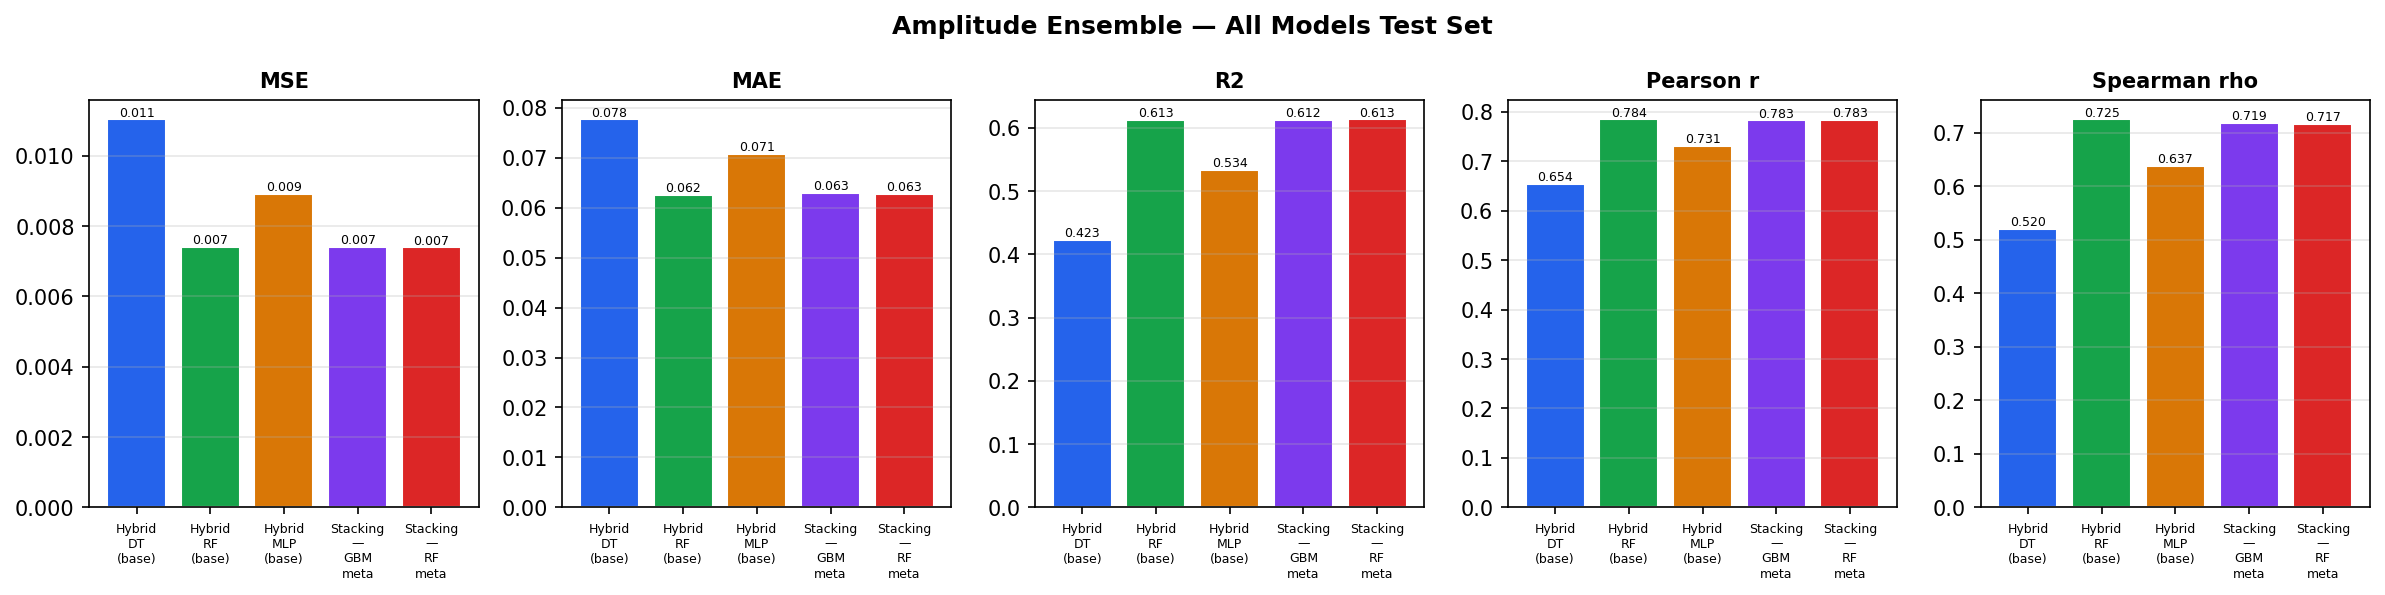

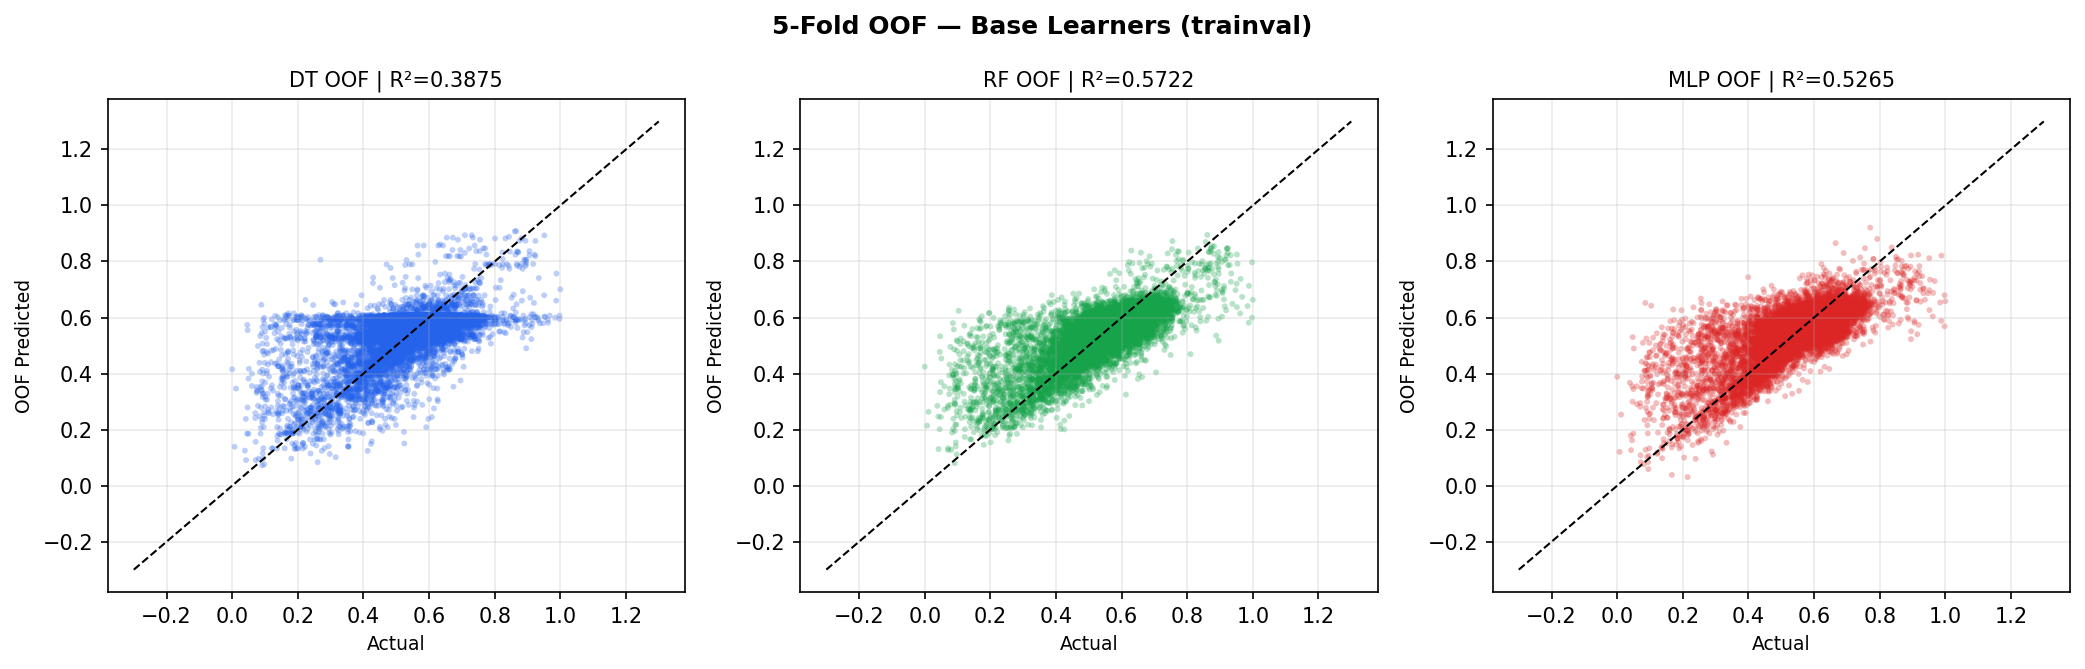

Figures saved to /home/host1-vm4/cache_quantum_amplitude_ensemble_final_pub/figures


In [ ]:
# ── Cell 15 : Publication Figures ────────────────────────────────────────

MODEL_COLORS = {
    'Hybrid DT (base)':   '#2563EB',
    'Hybrid RF (base)':   '#16A34A',
    'Hybrid MLP (base)':  '#D97706',
    'Stacking — GBM meta': '#7C3AED',
    'Stacking — RF meta':  '#DC2626'
}

# ── Figure 2: Predicted vs Actual — GBM stacking ──────────────────────────
y_gbm = preds['Stacking — GBM meta']
fig, ax = plt.subplots(figsize=(5.5, 5), dpi=150)
lims = [min(Y_test.min(), y_gbm.min()) - 0.3, max(Y_test.max(), y_gbm.max()) + 0.3]
ax.scatter(Y_test, y_gbm, alpha=0.4, s=14, color='#7C3AED', edgecolors='none')
ax.plot(lims, lims, 'k--', linewidth=1, label='y = x')
ax.set_xlim(lims); ax.set_ylim(lims)
r2v = results_df.loc['Stacking — GBM meta', 'R2']
prv = results_df.loc['Stacking — GBM meta', 'Pearson r']
srv = results_df.loc['Stacking — GBM meta', 'Spearman rho']
ax.set_title(f'Stacking GBM meta\nR²={r2v:.4f}  r={prv:.4f}  ρ={srv:.4f}', fontsize=10)
ax.set_xlabel('Actual LN_IC50', fontsize=11)
ax.set_ylabel('Predicted LN_IC50', fontsize=11)
ax.legend(fontsize=9); ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(os.path.join(FIGDIR, 'fig2_pred_vs_actual_stack.png'), dpi=300, bbox_inches='tight')
plt.show()

# ── Figure 3: All models metrics bar ───────────────────────────────────
metrics_bar = ['MSE', 'MAE', 'R2', 'Pearson r', 'Spearman rho']
model_labels = results_df.index.tolist()
colors = [MODEL_COLORS.get(l, '#888888') for l in model_labels]

fig, axes = plt.subplots(1, len(metrics_bar), figsize=(16, 4), dpi=150)
for ax, metric in zip(axes, metrics_bar):
    vals = results_df[metric].values
    bars = ax.bar(range(len(model_labels)), vals, color=colors, edgecolor='white')
    ax.set_xticks(range(len(model_labels)))
    ax.set_xticklabels([l.replace(' ', '\n') for l in model_labels], fontsize=6)
    ax.set_title(metric, fontsize=10, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.003 * abs(max(vals) - min(vals)),
                f'{val:.3f}', ha='center', va='bottom', fontsize=6)

plt.suptitle('Amplitude Ensemble — All Models Test Set',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGDIR, 'fig3_metrics_bar.png'), dpi=300, bbox_inches='tight')
plt.show()

# ── Figure 4: OOF scatter (base learners) ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), dpi=150)
for ax, (clf_name, _) in zip(axes, BASE_LEARNERS):
    preds_oof = oof_preds[clf_name]
    r2_oof_v  = r2_score(Y_trainval, preds_oof)
    lims_oof  = [min(Y_trainval.min(), preds_oof.min()) - 0.3,
                 max(Y_trainval.max(), preds_oof.max()) + 0.3]
    ax.scatter(Y_trainval, preds_oof, alpha=0.3, s=8,
               color=LEARNER_COLORS[clf_name], edgecolors='none')
    ax.plot(lims_oof, lims_oof, 'k--', linewidth=1)
    ax.set_title(f'{clf_name.upper()} OOF | R²={r2_oof_v:.4f}', fontsize=10)
    ax.set_xlabel('Actual', fontsize=9)
    ax.set_ylabel('OOF Predicted', fontsize=9)
    ax.grid(True, alpha=0.25)

plt.suptitle(f'{N_SPLITS_CV}-Fold OOF — Base Learners (trainval)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGDIR, 'fig4_oof_scatter.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f'Figures saved to {os.path.abspath(FIGDIR)}')

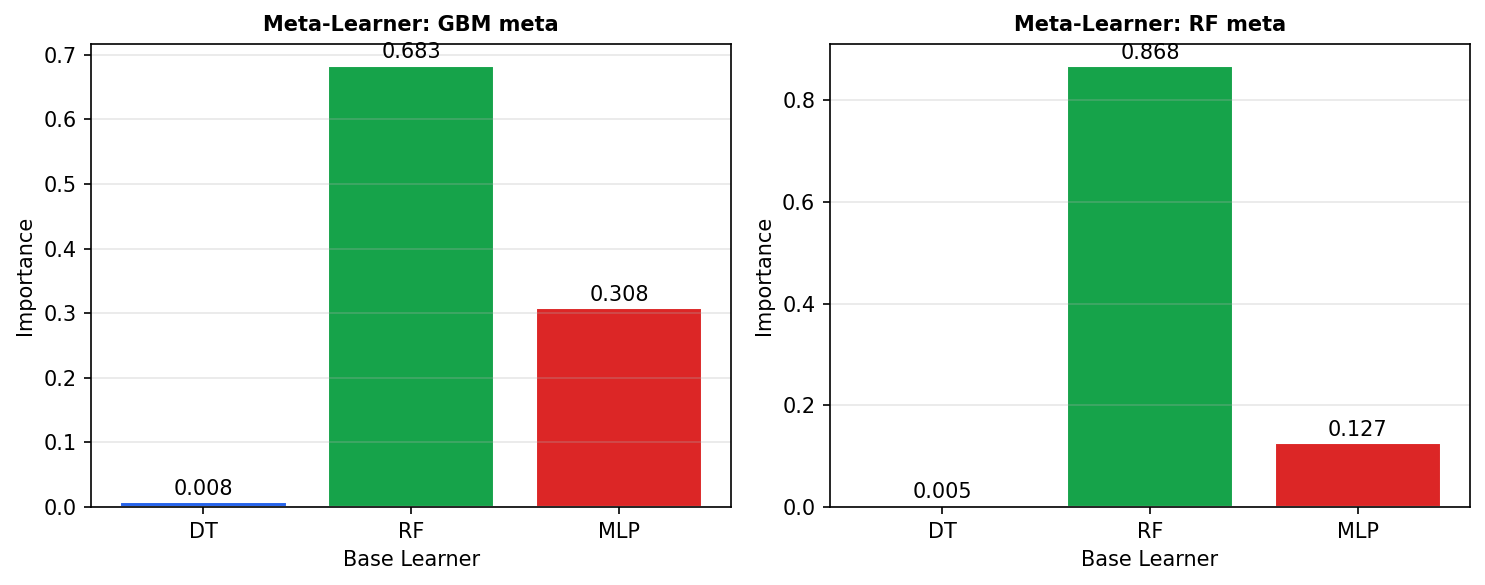

In [ ]:
# ── Cell 16 : Meta-Learner Feature Importance ─────────────────────────────

learner_names = [n.upper() for n, _ in BASE_LEARNERS]

fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=150)
for ax, (meta_model, meta_label) in zip(axes, [
    (meta_gbm, 'GBM meta'),
    (meta_rf,  'RF meta')
]):
    imp = meta_model.feature_importances_
    bars = ax.bar(learner_names, imp,
                  color=[LEARNER_COLORS[n] for n, _ in BASE_LEARNERS],
                  edgecolor='white')
    ax.set_xlabel('Base Learner', fontsize=10)
    ax.set_ylabel('Importance', fontsize=10)
    ax.set_title(f'Meta-Learner: {meta_label}', fontsize=10, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, imp):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(FIGDIR, 'fig5_meta_importance.png'), dpi=300, bbox_inches='tight')
plt.show()

/home/host1-vm4/miniconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/host1-vm4/miniconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/host1-vm4/miniconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


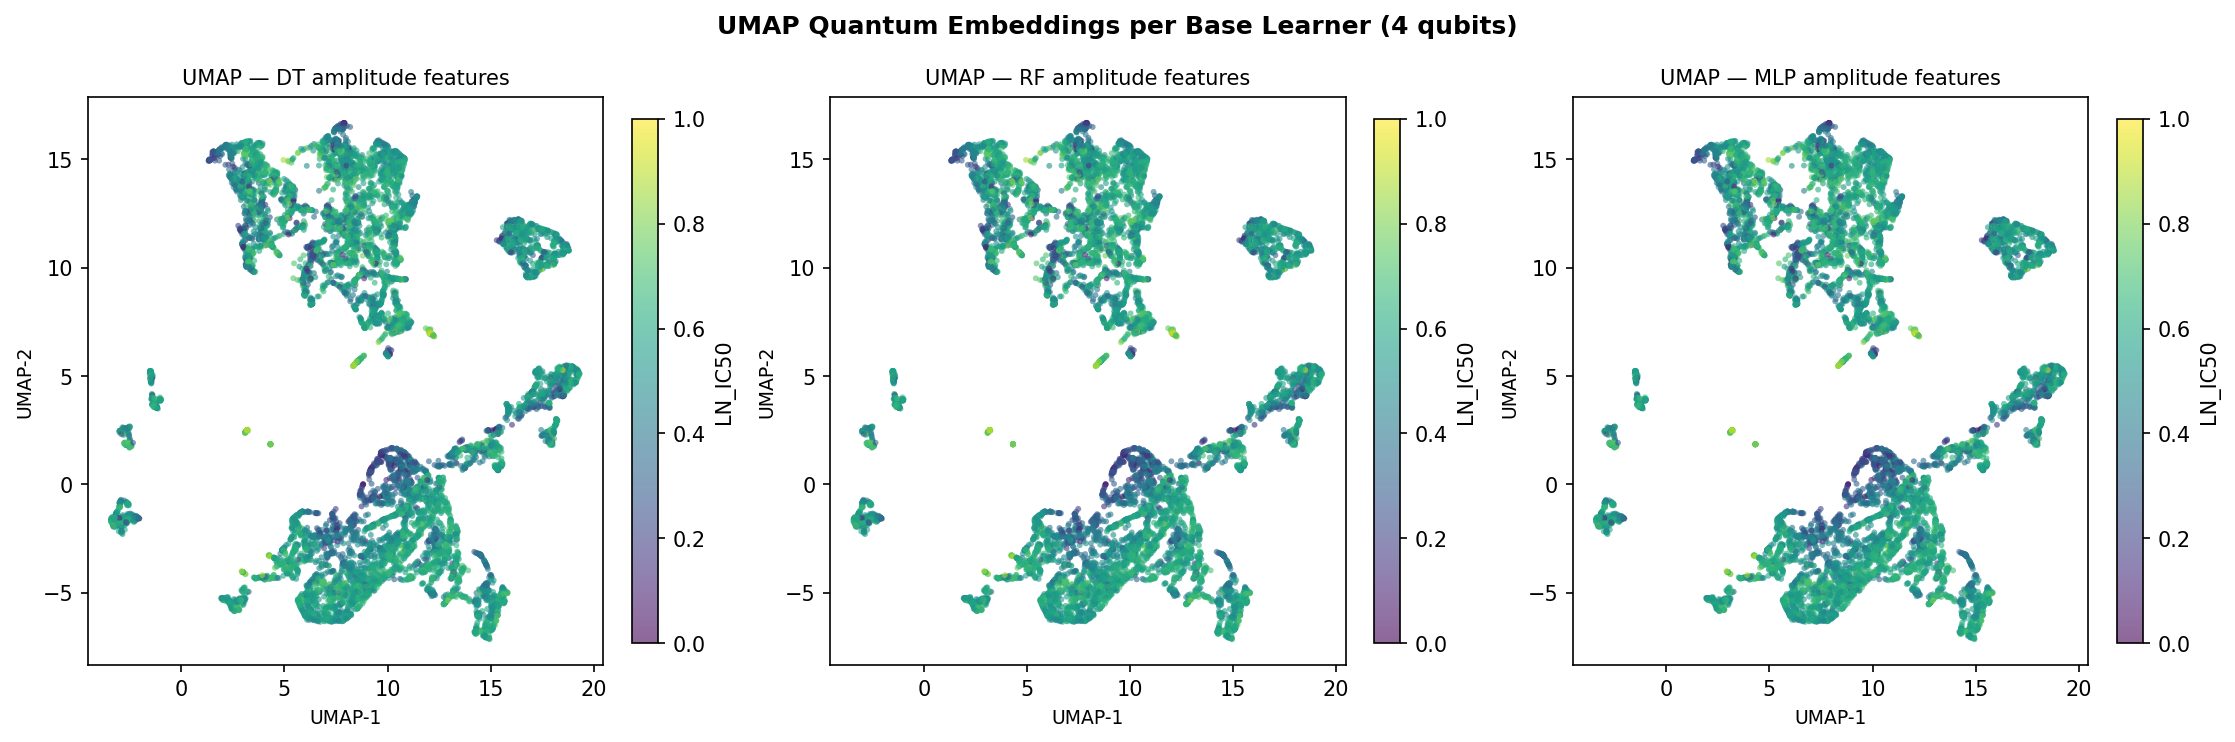

In [ ]:
# ── Cell 17 : UMAP of Quantum Embeddings per Base Learner ───────────────────
if UMAP_AVAILABLE:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=150)
    for ax, (clf_name, _) in zip(axes, BASE_LEARNERS):
        Xq_tv = qfeatures_tv[clf_name]
        reducer = umap.UMAP(n_components=2, random_state=SEED,
                            n_neighbors=15, min_dist=0.1)
        X_2d = reducer.fit_transform(Xq_tv)
        sc = ax.scatter(X_2d[:, 0], X_2d[:, 1],
                        c=Y_trainval, cmap='viridis',
                        s=8, alpha=0.6, edgecolors='none')
        plt.colorbar(sc, ax=ax, label='LN_IC50', fraction=0.046)
        ax.set_title(f'UMAP — {clf_name.upper()} amplitude features', fontsize=10)
        ax.set_xlabel('UMAP-1', fontsize=9)
        ax.set_ylabel('UMAP-2', fontsize=9)

    plt.suptitle(f'UMAP Quantum Embeddings per Base Learner ({n_qubits} qubits)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(FIGDIR, 'fig6_umap.png'), dpi=300, bbox_inches='tight')
    plt.show()
else:
    print('UMAP not available. Install with: pip install umap-learn')